# 🪟 Abertura do projeto

Discente: Pedro Henrique Costa Cordeiro

Orientador: Eric Gorgens

## Pendentes:

🔲 Rodar para um propriedade

🔲 Incluir colação 10 do mapbiomas (projects/mapbiomas-public/assets/brazil/lulc/collection10/mapbiomas_brazil_collection10_coverage_v2)


## Concluídos:

✅ Atualizar fluxograma

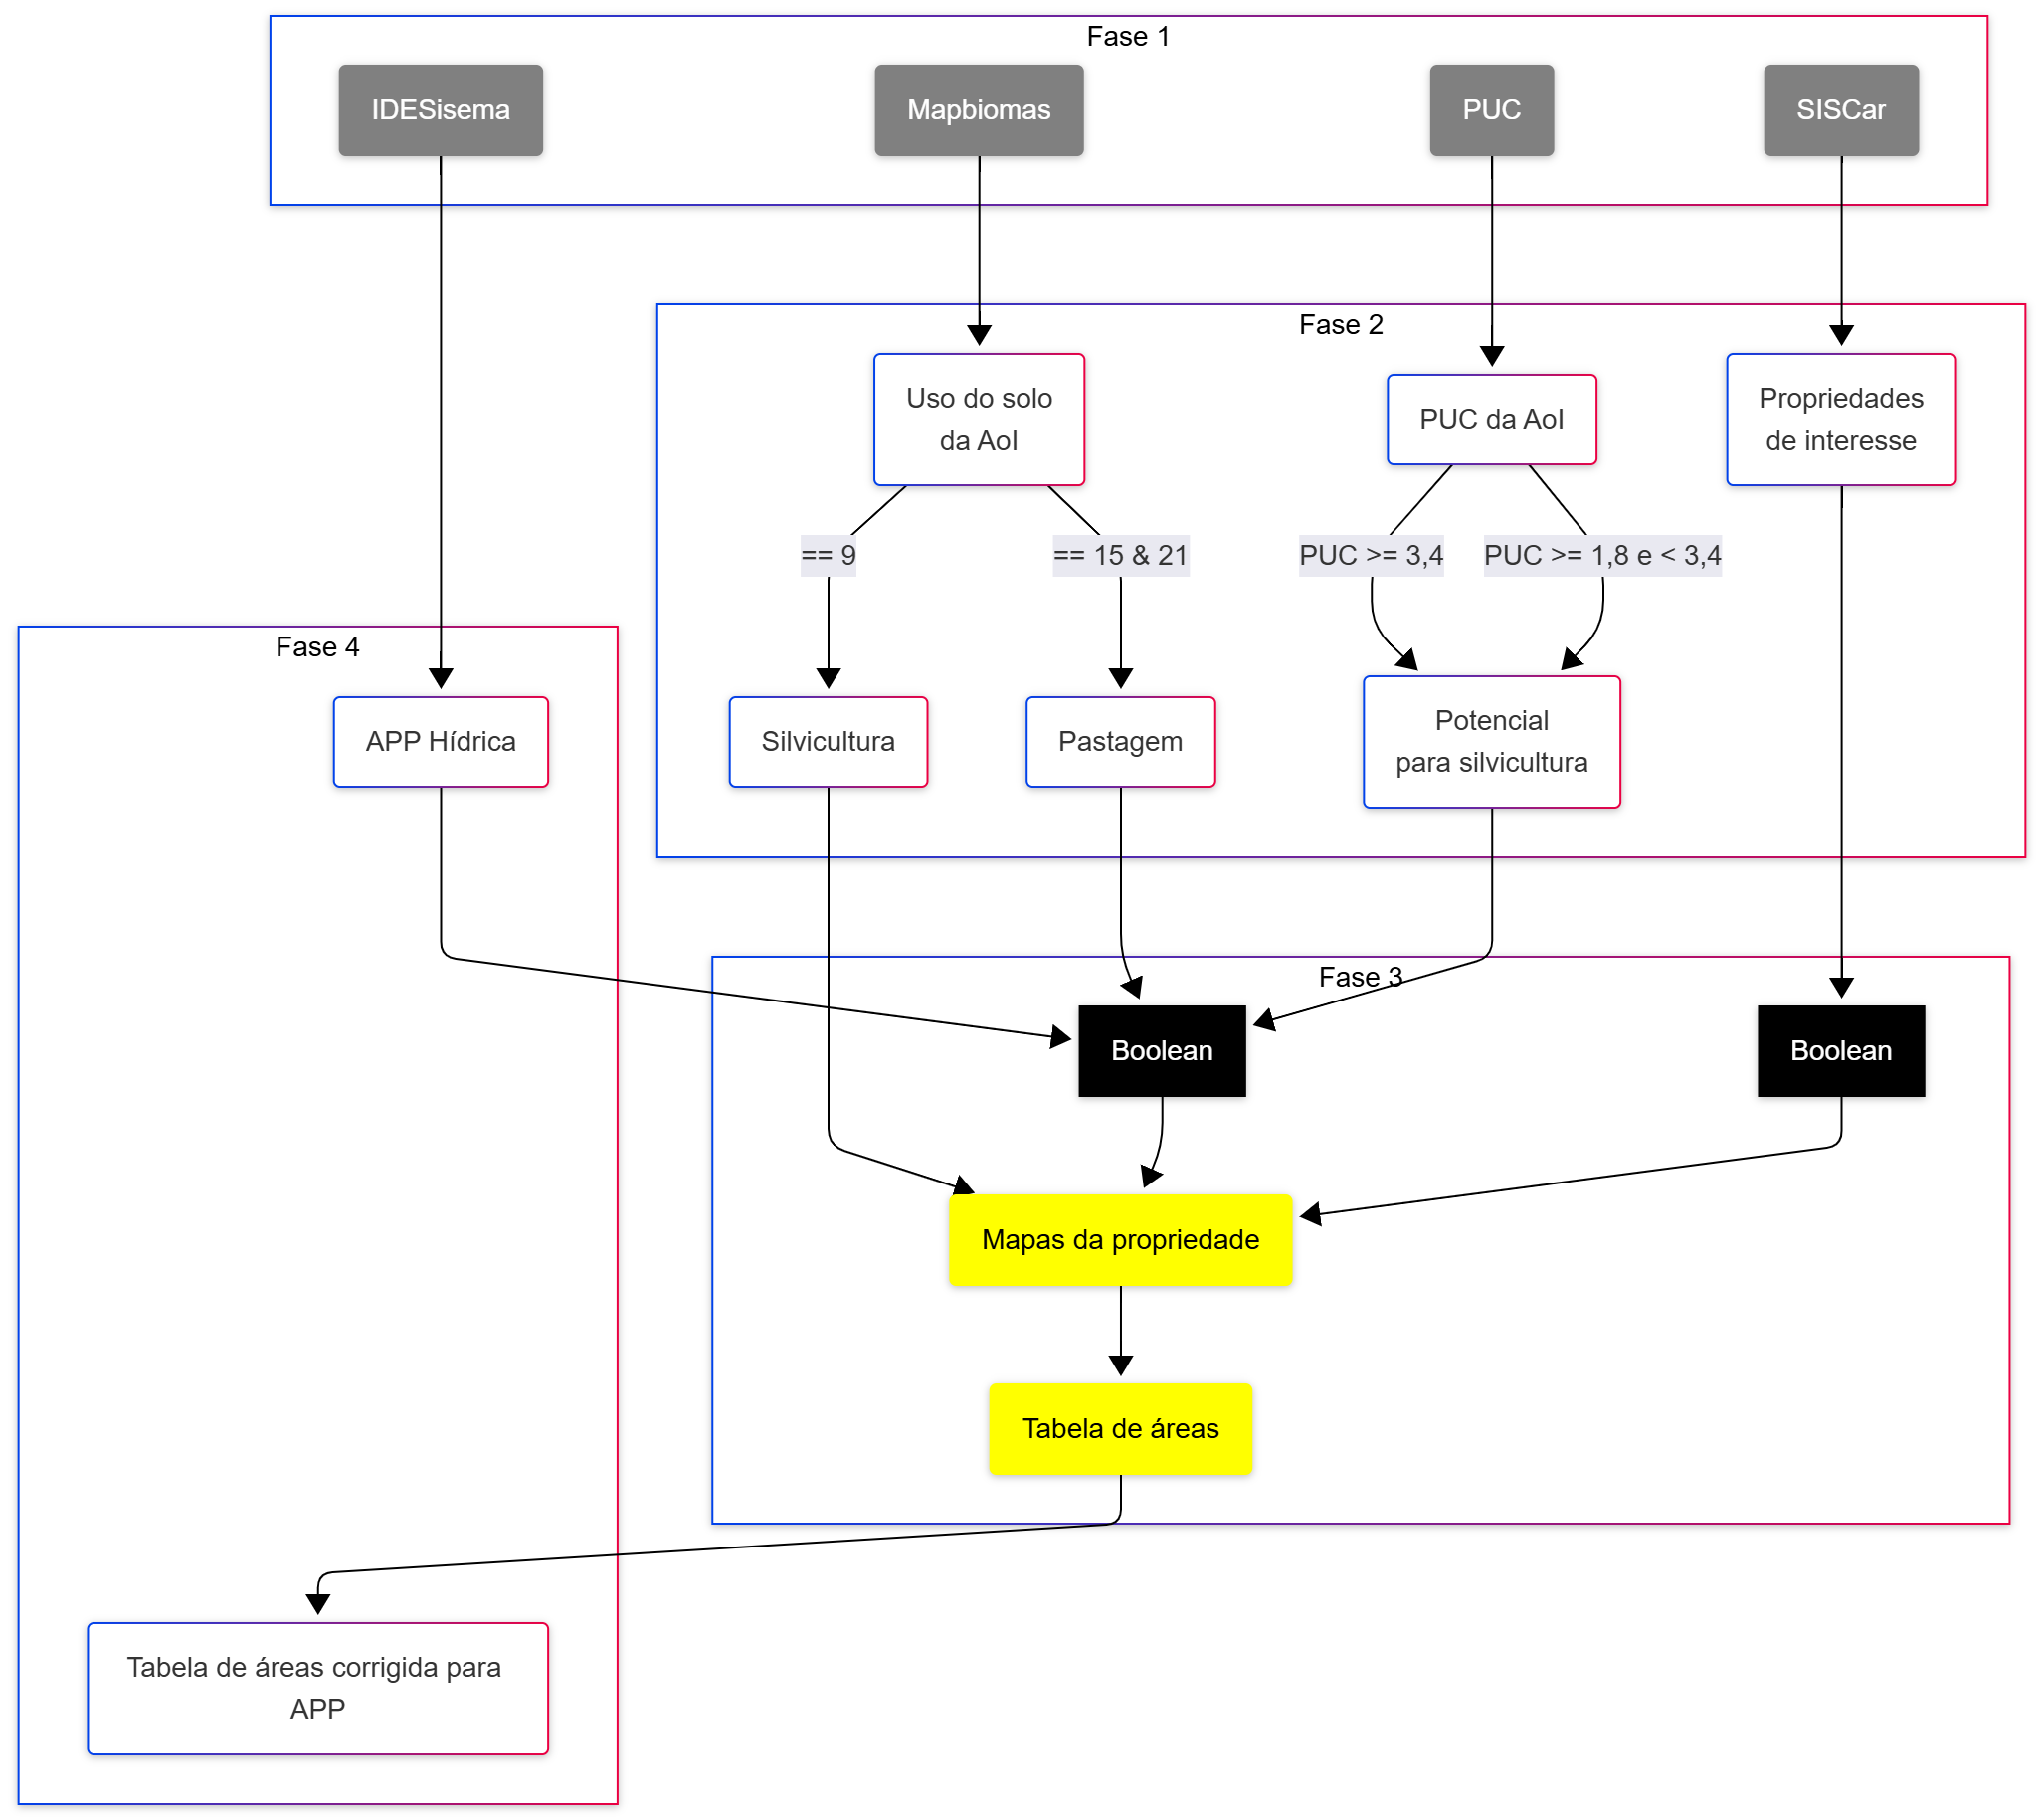

In [1]:
!pip install geemap -q
# fix geemap dependencies
!pip install pycrs -q
!pip install localtileserver -q

import ee
import geemap
import geopandas as gpd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.0/270.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 12.7 MB/s eta 0:00:00


In [2]:
ee.Authenticate()
#DICA!!! projeto
ee.Initialize(project='gee-python-ufvjm')

## ⚙️ Funções de apoio

In [15]:
def reclassifica_mapbiomas(mapbiomas_image, classes_dict):
  try:
    image_reclass = mapbiomas_image.where(mapbiomas_image.gt(0).And(mapbiomas_image.lte(1)), classes_dict[1])\
        .where(mapbiomas_image.gt(2).And(mapbiomas_image.lte(3)), classes_dict[3])\
        .where(mapbiomas_image.gt(3).And(mapbiomas_image.lte(4)), classes_dict[4])\
        .where(mapbiomas_image.gt(4).And(mapbiomas_image.lte(5)), classes_dict[5])\
        .where(mapbiomas_image.gt(5).And(mapbiomas_image.lte(6)), classes_dict[6])\
        .where(mapbiomas_image.gt(48).And(mapbiomas_image.lte(49)), classes_dict[49])\
        .where(mapbiomas_image.gt(9).And(mapbiomas_image.lte(10)), classes_dict[10])\
        .where(mapbiomas_image.gt(10).And(mapbiomas_image.lte(11)), classes_dict[11])\
        .where(mapbiomas_image.gt(11).And(mapbiomas_image.lte(12)), classes_dict[12])\
        .where(mapbiomas_image.gt(31).And(mapbiomas_image.lte(32)), classes_dict[32])\
        .where(mapbiomas_image.gt(28).And(mapbiomas_image.lte(29)), classes_dict[29])\
        .where(mapbiomas_image.gt(49).And(mapbiomas_image.lte(50)), classes_dict[50])\
        .where(mapbiomas_image.gt(12).And(mapbiomas_image.lte(13)), classes_dict[13])\
        .where(mapbiomas_image.gt(13).And(mapbiomas_image.lte(14)), classes_dict[14])\
        .where(mapbiomas_image.gt(14).And(mapbiomas_image.lte(15)), classes_dict[15])\
        .where(mapbiomas_image.gt(17).And(mapbiomas_image.lte(18)), classes_dict[18])\
        .where(mapbiomas_image.gt(18).And(mapbiomas_image.lte(19)), classes_dict[19])\
        .where(mapbiomas_image.gt(38).And(mapbiomas_image.lte(39)), classes_dict[39])\
        .where(mapbiomas_image.gt(19).And(mapbiomas_image.lte(20)), classes_dict[20])\
        .where(mapbiomas_image.gt(39).And(mapbiomas_image.lte(40)), classes_dict[40])\
        .where(mapbiomas_image.gt(61).And(mapbiomas_image.lte(62)), classes_dict[62])\
        .where(mapbiomas_image.gt(40).And(mapbiomas_image.lte(41)), classes_dict[41])\
        .where(mapbiomas_image.gt(35).And(mapbiomas_image.lte(36)), classes_dict[36])\
        .where(mapbiomas_image.gt(45).And(mapbiomas_image.lte(46)), classes_dict[46])\
        .where(mapbiomas_image.gt(46).And(mapbiomas_image.lte(47)), classes_dict[47])\
        .where(mapbiomas_image.gt(34).And(mapbiomas_image.lte(35)), classes_dict[35])\
        .where(mapbiomas_image.gt(47).And(mapbiomas_image.lte(48)), classes_dict[48])\
        .where(mapbiomas_image.gt(8).And(mapbiomas_image.lte(9)), classes_dict[9])\
        .where(mapbiomas_image.gt(20).And(mapbiomas_image.lte(21)), classes_dict[15])\
        .where(mapbiomas_image.gt(21).And(mapbiomas_image.lte(22)), classes_dict[22])\
        .where(mapbiomas_image.gt(22).And(mapbiomas_image.lte(23)), classes_dict[23])\
        .where(mapbiomas_image.gt(23).And(mapbiomas_image.lte(24)), classes_dict[24])\
        .where(mapbiomas_image.gt(29).And(mapbiomas_image.lte(30)), classes_dict[30])\
        .where(mapbiomas_image.gt(24).And(mapbiomas_image.lte(25)), classes_dict[25])\
        .where(mapbiomas_image.gt(25).And(mapbiomas_image.lte(26)), classes_dict[26])\
        .where(mapbiomas_image.gt(32).And(mapbiomas_image.lte(33)), classes_dict[33])\
        .where(mapbiomas_image.gt(30).And(mapbiomas_image.lte(31)), classes_dict[31])\
        .where(mapbiomas_image.gt(74).And(mapbiomas_image.lte(75)), classes_dict[75])
    return image_reclass
  except Exception as e:
      print(f"An error occurred: {e}")
      return None

In [16]:
reclass_mapbiomas = {
    1: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    49: 1,
    10: 1,
    11: 1,
    12: 1,
    32: 1,
    29: 1,
    50: 1,
    13: 1,
    14: 14,
    15: 15,
    18: 14,
    19: 14,
    39: 14,
    20: 14,
    40: 14,
    62: 14,
    41: 14,
    36: 14,
    46: 14,
    47: 14,
    35: 14,
    48: 14,
    9: 9,
    21: 15,
    22: 22,
    23: 22,
    24: 22,
    30: 22,
    25: 22,
    26: 26,
    33: 26,
    31: 26,
    27: 22,
    75: 22,
}

In [5]:
def classes_puc(puc_image):
  try:
    image_reclass = puc_image.where(puc_image.gt(4.2).And(puc_image.lte(5)), 5)\
      .where(puc_image.gt(3.4).And(puc_image.lte(4.2)), 4)\
      .where(puc_image.gt(2.6).And(puc_image.lte(3.4)), 3)\
      .where(puc_image.gt(1.8).And(puc_image.lte(2.6)), 2)\
      .where(puc_image.gte(1).And(puc_image.lte(1.8)), 1)
    return image_reclass
  except Exception as e:
      print(f"An error occurred: {e}")
      return None

In [6]:
def conflito_puc(puc_image, classes_dict):
  try:
    image_reclass = puc_image.where(puc_image.gt(0).And(puc_image.lte(1)), classes_dict[1])\
        .where(puc_image.gt(1).And(puc_image.lte(2)), classes_dict[2])\
        .where(puc_image.gt(2).And(puc_image.lte(3)), classes_dict[3])\
        .where(puc_image.gt(3).And(puc_image.lte(4)), classes_dict[4])\
        .where(puc_image.gt(4).And(puc_image.lte(5)), classes_dict[5])
    return image_reclass
  except Exception as e:
      print(f"An error occurred: {e}")
      return None

In [7]:
conflito_code = {
    1: 2,
    2: 1,
    3: 1,
    4: 0,
    5: 0,
}

# 💽 Fase 1 - Base de dados

In [25]:
estados = ee.FeatureCollection('projects/gee-python-ufvjm/assets/administrativas/EstadosBR')
loi = estados.filter(ee.Filter.eq('SIGLA_UF', 'MG'))

declividadePesos = ee.Image("projects/ee-nepzapufvjm/assets/declividade_mg_pesos")

litoPesos = ee.Image("users/egorgens/puc/tipo_mg_pesos")

soloEmbrapaPesos = ee.Image("users/nepzapufvjm/puc/solos_embrapa_puc")
soloIBGEPesos = ee.Image("users/nepzapufvjm/puc/solos_ibge_puc")
soloUFVPesos = ee.Image("users/nepzapufvjm/puc/solos_ufv_puc")

pucIBGE = ee.Image("projects/ee-nepzapufvjm/assets/puc_mg_ibge")
pucEmbrapa = ee.Image("projects/ee-nepzapufvjm/assets/puc_mg_embrapa")
pucUFV = ee.Image("projects/ee-nepzapufvjm/assets/puc_mg_ufv")

In [ ]:
# task = ee.batch.Export.image.toDrive(
#     image=pucUFV,
#     description='puc minas gerais',
#     folder='Google Earth',        # Nome da pasta no Google Drive
#     fileNamePrefix='puc_mg',
#     region=loi.geometry(), # Convert FeatureCollection to Geometry
#     scale=30,
#     crs='EPSG:4326',
#     maxPixels=1400000000
# )


# # Inicie a task
# task.start()

# 🌎 Área de interesse

## Ponto de interesse

In [ ]:
#xlong, ylat = -44.933, -17.334 #Pirapora
#xlong, ylat = -43.852, -16.727 #Montes Claros
#xlong, ylat = -42.893, -16.567 #Grão Mogol

In [ ]:
#DICA!!! getInfo()
point = ee.Geometry.Point(xlong, ylat)
loi = point.buffer(25000)

## Polígono de interesse

In [40]:
propriedade_shp = "/content/drive/MyDrive/Colab Notebooks/man-silviPUC/LASSANCE.shp"
loi = geemap.shp_to_ee(propriedade_shp)

## Inicializa mapa

In [9]:
Map = geemap.Map()
Map.centerObject(loi, 8)
Map.addLayer(loi, {}, "Área de interesse")

# 🗺 Mapbiomas

In [18]:
# mapbiomas = ee.Image('projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1')
# mb22 = mapbiomas.select('classification_2022').clip(loi)
# mb22resume = reclassifica_mapbiomas(mb22, reclass_mapbiomas)

mapbiomas = ee.Image('projects/mapbiomas-public/assets/brazil/lulc/collection10/mapbiomas_brazil_collection10_coverage_v2')
mb24 = mapbiomas.select('classification_2024').clip(loi)
mb24resume = reclassifica_mapbiomas(mb24, reclass_mapbiomas)

In [21]:
vis_mapbiomas = {
    'min': 1,'max': 75,
    'palette': ['32a65e', 'ffffff', '1f8d49', '7dc975', '04381d', '026975', 'ffffff', 'ffffff', '7a5900', 'ad975a',
                '519799', 'd6bc74', 'd89f5c', 'FFFFB2', 'edde8e', 'ffffff', 'ffffff', 'E974ED', 'C27BA0', 'db7093',
                'ffefc3', 'd4271e', 'ffa07a', 'd4271e', 'db4d4f', '0000FF', 'ffffff', 'ffffff', 'ffaa5f', '9c0027',
                '091077', 'fc8114', '2532e4', 'ffffff', '9065d0', 'd082de', 'ffffff', 'ffffff', 'f5b3c8', 'c71585',
                'f54ca9', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'd68fe2', '9932cc', 'e6ccff', '02d659', 'ad5100',
                'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff',
                'ffffff', 'ff69b4', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff', 'ffffff',
                'ffffff', 'ffffff', 'ffffff', 'ffffff', 'd4271e']
}

Map.addLayer(mb24resume, vis_mapbiomas, 'Uso do solo', True, 1)

In [23]:
# cria mascara para classes de uso do solo
silvicultura_mask = mb24resume.eq(9)
pastagem_mask = mb24resume.eq(15)
agricultura_mask = mb24resume.eq(14)
natural_mask = mb24resume.eq(1)
semVegetacao_mask = mb24resume.eq(22)

# 🔠 PUC

In [41]:
vis_puc = {
  'min': 1,
  'max': 5,
  'palette': ['ff0000', 'ff4d4d', 'ffffff', 'add8e6', '0000ff']
}

Map.addLayer(declividadePesos.clip(loi), vis_puc, 'PUC declividade', True, 1)
Map.addLayer(litoPesos.clip(loi), vis_puc, 'PUC litologia', True, 1)
Map.addLayer(soloIBGEPesos.clip(loi), vis_puc, 'PUC solos', True, 1)

In [42]:
pucIBGE_classes = classes_puc(pucIBGE)

Map.addLayer(pucIBGE_classes.clip(loi), vis_puc, 'PUC ref.IBGE', True, 1)

# 🔀 Análise de compatibilidade

In [43]:
conflito_silvicultura = conflito_puc(pucIBGE_classes, conflito_code)

vis_compatibilidade = {
    'min': 0,'max': 2,
    'palette': ['7dc975', 'fc8114', 'd4271e']
}

Map.addLayer(conflito_silvicultura.clip(loi), vis_compatibilidade, "Conflito Silvicultura", True, 1)

In [ ]:
# conflito_silvicultura_filtered = conflito_silvicultura.focalMedian(30, 'circle', 'pixels', 2)
# Map.addLayer(conflito_silvicultura_filtered, vis_compatibilidade, "Conflito Silvicultura Filtered", True, 1)

In [44]:
# cria mascara para potencial de silvicultura
#alto_potencial_silvicultura_mask = conflito_silvicultura.eq(0).updateMask(pastagem_mask)
#intermediario_potencial_silvicultura_mask = conflito_silvicultura.eq(1).updateMask(pastagem_mask)
#sem_potencial_silvicultura_mask = conflito_silvicultura.eq(2).updateMask(pastagem_mask)

potencial_silvicultura_mask = conflito_silvicultura.updateMask(pastagem_mask)

# vis_potencial = {
#     'min': 0,'max': 1,
#     'palette': ['7dc975', 'E974ED']
# }

In [45]:
# Map.addLayer(alto_potencial_silvicultura_mask, vis_potencial, "Alto Potencial Silvicultura", True, 1)
# Map.addLayer(intermediario_potencial_silvicultura_mask, vis_potencial, "Médio Potencial Silvicultura", True, 1)
# Map.addLayer(sem_potencial_silvicultura_mask, vis_potencial, "Sem Potencial Silvicultura", True, 1)

Map.addLayer(potencial_silvicultura_mask.clip(loi), vis_compatibilidade, "Potencial Expensão Silvicultura", True, 1)

# SiSCar

# 👀 Dashboard integrado

In [ ]:
Map